In [25]:
# Data Science Project: Individual Planning Report
# Student: Ryan Wong
# Date: November 14

# Load required libraries
library(tidyverse)
library(knitr)

# Load the data
players <- read_csv("dsci100-project-004-10/players.csv")
sessions <- read_csv("dsci100-project-004-10/sessions.csv")

# Display basic information
cat("Players dataset dimensions:", dim(players)[1], "rows,", dim(players)[2], "columns\n")
cat("Sessions dataset dimensions:", dim(sessions)[1], "rows,", dim(sessions)[2], "columns\n")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Players dataset dimensions: 196 rows, 7 columns
Sessions dataset dimensions: 1535 rows, 5 columns


# 1. Data Description
The data was collected from a UBC Minecraft research server. Each player's activity is automatically logged, including session start/end times, duration, and interactions. Player demographic information (age, gender, experience level) was self-reported.
### Data Sources
The dataset consists of two CSV files:
- **players.csv**: Player demographic and profile information
- **sessions.csv**: Individual gameplay session records

In [44]:
# Create summary table for players dataset
player_vars <- data.frame(
  Variable = names(players),
  Type = sapply(players, function(x) class(x)[1]),
  Description = c(
    "Player experience level (Beginner, Amateur, Regular, Veteran, Pro)",
    "Whether player subscribed to newsletter (TRUE/FALSE)",
    "Anonymized email identifier",
    "Total hours played on the server",
    "Player name",
    "Player gender identity",
    "Player age in years"
  ),
  Missing = sapply(players, function(x) sum(is.na(x)))
)
kable(player_vars, caption = "Players Dataset Variable Summary")



Table: Players Dataset Variable Summary

|             |Variable     |Type      |Description                                                        | Missing|
|:------------|:------------|:---------|:------------------------------------------------------------------|-------:|
|experience   |experience   |character |Player experience level (Beginner, Amateur, Regular, Veteran, Pro) |       0|
|subscribe    |subscribe    |logical   |Whether player subscribed to newsletter (TRUE/FALSE)               |       0|
|hashedEmail  |hashedEmail  |character |Anonymized email identifier                                        |       0|
|played_hours |played_hours |numeric   |Total hours played on the server                                   |       0|
|name         |name         |character |Player name                                                        |       0|
|gender       |gender       |character |Player gender identity                                             |       0|
|Age         

In [27]:
# Summary table for sessions dataset
session_vars <- data.frame(
  Variable = names(sessions),
  Type = sapply(sessions, function(x) class(x)[1]),
  Description = c(
    "Anonymized email identifier (links to players table)",
    "Session start time (formatted)",
    "Session end time (formatted)",
    "Session start time (Unix timestamp)",
    "Session end time (Unix timestamp)"
  ),
  Missing = sapply(sessions, function(x) sum(is.na(x)))
)

kable(session_vars, caption = "Sessions Dataset Variable Summary")



Table: Sessions Dataset Variable Summary

|                    |Variable            |Type      |Description                                          | Missing|
|:-------------------|:-------------------|:---------|:----------------------------------------------------|-------:|
|hashedEmail         |hashedEmail         |character |Anonymized email identifier (links to players table) |       0|
|start_time          |start_time          |character |Session start time (formatted)                       |       0|
|end_time            |end_time            |character |Session end time (formatted)                         |       2|
|original_start_time |original_start_time |numeric   |Session start time (Unix timestamp)                  |       0|
|original_end_time   |original_end_time   |numeric   |Session end time (Unix timestamp)                    |       2|

In [28]:
# Summary statistics
cat("\n**Dataset Sizes:**\n")
cat("- Total unique players:", nrow(players), "\n")
cat("- Total gameplay sessions:", nrow(sessions), "\n")
cat("- Sessions with missing end times:", sum(is.na(sessions$end_time)), "\n")

# Distribution of categorical variables
cat("\n**Experience Level Distribution:**\n")
print(table(players$experience))

cat("\n**Gender Distribution:**\n")
print(table(players$gender))

cat("\n**Subscription Rate:**\n")
print(table(players$subscribe))


**Dataset Sizes:**
- Total unique players: 196 
- Total gameplay sessions: 1535 
- Sessions with missing end times: 2 

**Experience Level Distribution:**

 Amateur Beginner      Pro  Regular  Veteran 
      63       35       14       36       48 

**Gender Distribution:**

          Agender            Female              Male        Non-binary 
                2                37               124                15 
            Other Prefer not to say      Two-Spirited 
                1                11                 6 

**Subscription Rate:**

FALSE  TRUE 
   52   144 


In [24]:
# Calculate means for quantitative variables
quantitative_means <- data.frame(
  Variable = c("played_hours", "Age"),
  Mean = c(
    round(mean(players$played_hours, na.rm = TRUE), 2),
    round(mean(as.numeric(players$Age), na.rm = TRUE), 2)
  ),
  SD = c(
    round(sd(players$played_hours, na.rm = TRUE), 2),
    round(sd(as.numeric(players$Age), na.rm = TRUE), 2)
  ),
  Min = c(
    round(min(players$played_hours, na.rm = TRUE), 2),
    round(min(as.numeric(players$Age), na.rm = TRUE), 2)
  ),
  Max = c(
    round(max(players$played_hours, na.rm = TRUE), 2),
    round(max(as.numeric(players$Age), na.rm = TRUE), 2)
  ),
  N_Missing = c(
    sum(is.na(players$played_hours)),
    sum(is.na(as.numeric(players$Age)))
  )
)

kable(quantitative_means, caption = "Summary Statistics for Quantitative Variables")



Table: Summary Statistics for Quantitative Variables

|Variable     |  Mean|    SD| Min|   Max| N_Missing|
|:------------|-----:|-----:|---:|-----:|---------:|
|played_hours |  5.85| 28.36|   0| 223.1|         0|
|Age          | 21.14|  7.39|   9|  58.0|         2|

### Data Quality Issues

**Observed Issues:**
- 2 sessions have missing end times (incomplete sessions)
- Age variable contains "NA" strings that need conversion
- Played_hours shows extreme outliers (maximum > 200 hours)
- Gender has multiple categories with small sample sizes

**Potential Issues:**
- Self-reported demographic data may have accuracy concerns
- Session timestamps need timezone considerations
- Some players have zero sessions recorded

## 2. Research Question

### Broad Question
**Question 2:** "We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts."

### Specific Research Question
**Can player characteristics (experience level, age, gender, and subscription status) predict the total number of gameplay sessions contributed by a player in the Minecraft research server dataset?**

**Response Variable:** Number of sessions per player (count data, derived from sessions.csv)

**Explanatory Variables:**
- Experience level (categorical: Beginner, Amateur, Regular, Veteran, Pro)
- Age (numeric, in years)
- Gender (categorical)
- Newsletter subscription status (binary: TRUE/FALSE)

### How the Data Addresses the Question

The datasets enable this analysis by:
1. Linking players to sessions via hashedEmail to calculate session counts per player
2. Providing demographic and behavioral characteristics that may predict engagement
3. Measuring data contribution through session counts as a proxy for research value
4. Supporting targeted recruitment by identifying high-value player profiles

## 3. Exploratory Data Analysis and Visualization

### Data Wrangling

In [45]:
# Count sessions per player
session_counts <- sessions %>%
  filter(!is.na(end_time)) %>% 
  group_by(hashedEmail) %>%
  summarise(num_sessions = n())

# Join with player data
analysis_data <- players %>%
  left_join(session_counts, by = "hashedEmail") %>%
  mutate(
    num_sessions = replace_na(num_sessions, 0),
    Age = as.numeric(Age),  
    experience = factor(experience, 
                       levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
                       ordered = TRUE)
  )

cat("Analysis dataset created with", nrow(analysis_data), "players\n")
cat("Players with at least one session:", sum(analysis_data$num_sessions > 0), "\n")
cat("Average sessions per player:", round(mean(analysis_data$num_sessions), 2), "\n")

Analysis dataset created with 196 players
Players with at least one session: 125 
Average sessions per player: 7.82 


### Visualization 1: Sessions by Experience Level

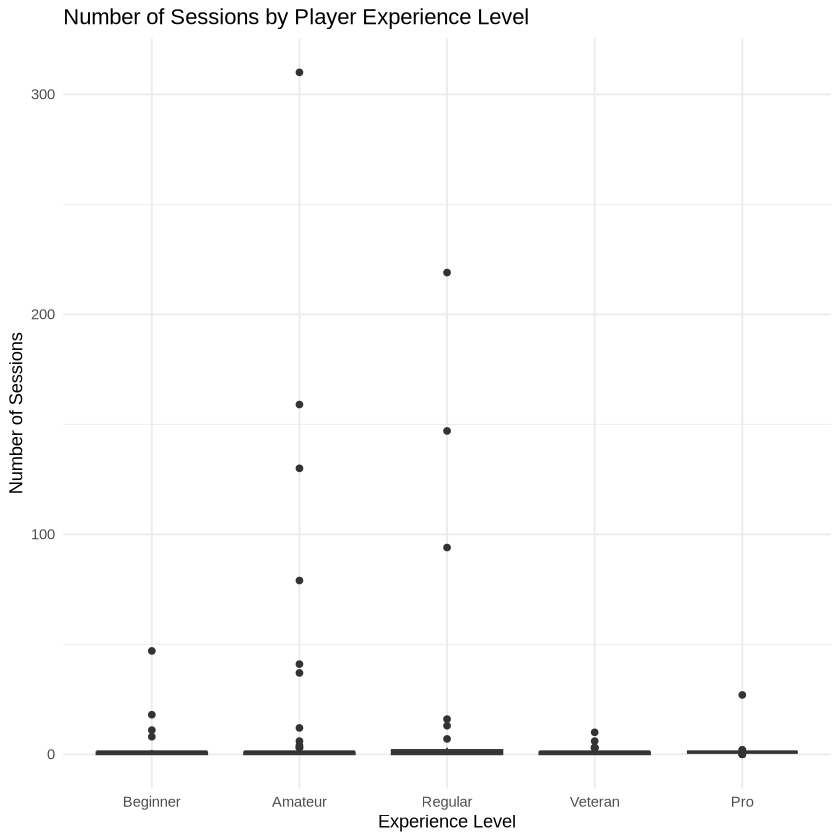

In [59]:
ggplot(analysis_data, aes(x = experience, y = num_sessions)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "Number of Sessions by Player Experience Level",
    x = "Experience Level",
    y = "Number of Sessions"
  ) +
  theme_minimal()

**What I learned:** Most players across all experience levels have relatively few sessions (the boxes are all close to zero), but each experience level has some players with many more sessions (shown by the dots above). Amateur and Regular players seem to have the most high-session outliers, which is interesting. I expected Pro players to have the most sessions, but that's not clearly the case. This suggests that experience level alone might not be a strong predictor, or that the relationship is more complicated than I initially thought. The variation within each group is quite large, which means other factors (like age, gender, or subscription status) might also be important for predicting session counts.

### Visualization 2: Age vs Sessions

`geom_smooth()` using formula = 'y ~ x'


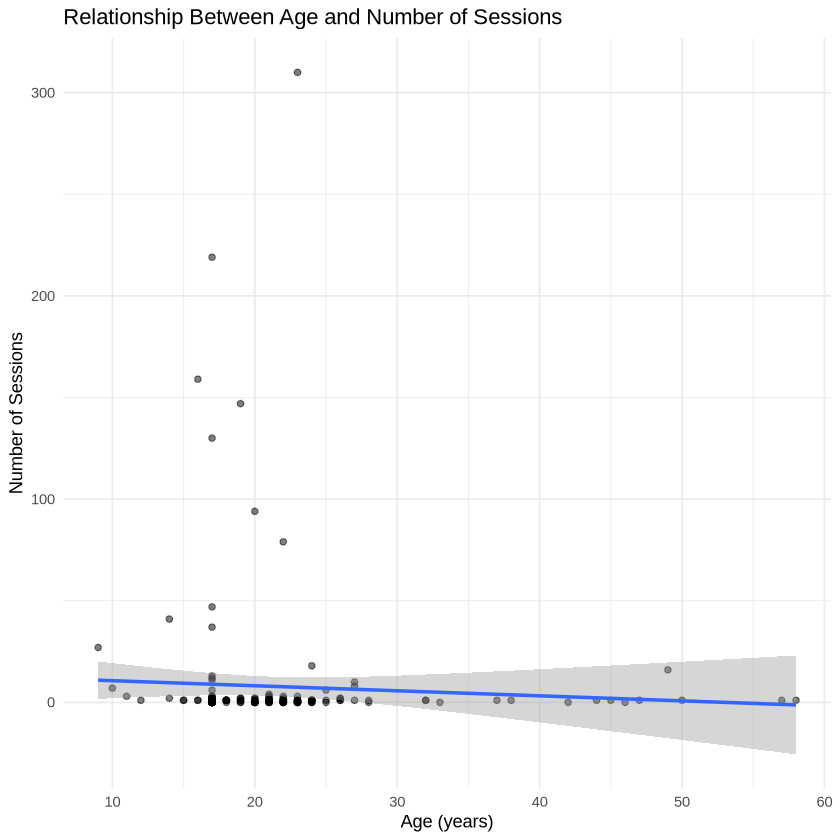

In [62]:
# Remove players with missing age
analysis_data_age <- analysis_data %>%
  mutate(Age_numeric = as.numeric(Age)) %>%
  filter(!is.na(Age_numeric))

ggplot(analysis_data_age, aes(x = Age_numeric, y = num_sessions)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm") +
  labs(
    title = "Relationship Between Age and Number of Sessions",
    x = "Age (years)",
    y = "Number of Sessions"
  ) +
  theme_minimal()

**What I learned:** The relationship between age and number of sessions is very weak, as the trend line is almost flat. Most players across all ages have very few sessions (most points are clustered near the bottom), but there are a few younger players (around ages 15-25) who have many more sessions than average. The slight downward slope suggests that older players might play slightly less, but this pattern is not strong. This tells me that age alone is probably not a very good predictor of how many sessions a player will have. I might need to use age together with other variables (like experience level or subscription status) to make better predictions.

### Visualization 3: Subscription Status and Engagement

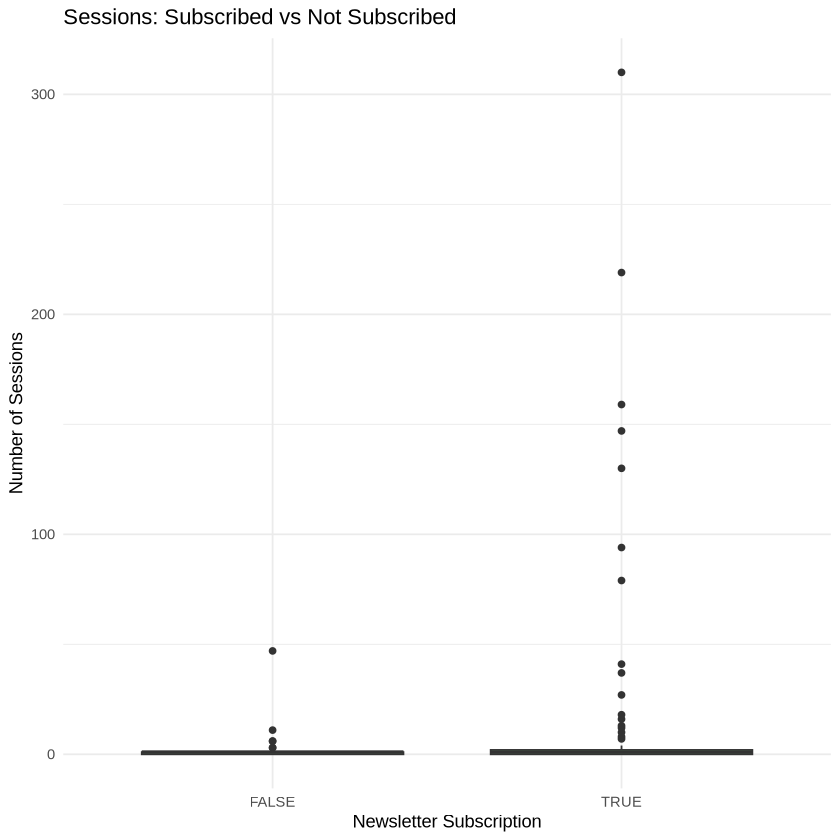

In [63]:
ggplot(analysis_data, aes(x = subscribe, y = num_sessions)) +
  geom_boxplot(fill = "lightgreen") +
  labs(
    title = "Sessions: Subscribed vs Not Subscribed",
    x = "Newsletter Subscription",
    y = "Number of Sessions"
  ) +
  theme_minimal()

**What I learned:** This graph shows an interesting pattern: while most players in both groups (subscribed and not subscribed) have very few sessions, the subscribed players have many more high-session outliers. This means that players who subscribe to the newsletter are more likely to be the dedicated, high-engagement players who play many sessions. The non-subscribed group has only a few players with high session counts. This suggests that subscription status could be a useful predictor, or it might mean that players who are already engaged are more likely to subscribe. 

## 4. Methods and Plan

### My Proposed Method

I will use **k-nearest neighbors (k-nn) regression** to predict the number of sessions.

### Why This Method?

I chose k-nn regression because:
- I learned it in DSCI 100 and I know how to use it
- It works for predicting numbers (like session counts)
- It can use multiple predictors at the same time
- I don't need to worry about whether my data follows a specific pattern

### Required Assumptions

For k-nn regression to work well:
- Players with similar characteristics should have similar session counts
- My predictors (experience, age, gender, subscribe) should actually matter for predicting sessions
- I need enough data to find neighbors

### Potential Problems

Some issues I might run into:
- K-nn needs me to pick the right value for k, and I'm not sure what it should be
- Some of my variables are categories (like experience level) and some are numbers (like age), which might make it harder
- Most players have very few sessions, so the model might just predict low numbers for everyone
- I don't know if k-nn will handle the outliers (players with 100+ sessions) well

### How I'll Compare and Select the Model

To find the best k value:
1. I'll try different k values like k = 1, 5, 10, 15, and 20
2. For each k, I'll use cross-validation to see how well it predicts
3. I'll look at the RMSPE (prediction error) - lower is better
4. I'll pick the k with the lowest RMSPE from cross-validation
5. Then I'll test that final model on my test data

### Data Processing Plan

Steps I'll follow:

1. Clean the data: Remove players who don't have age information
2. Split the data: Divide into 75% training and 25% test, using `set.seed(100)` so I can reproduce my results
3. Preprocess: Use `recipe()` and `step_scale()` to standardize my predictors so they're all on the same scale
4. Cross-validation: Use `vfold_cv()` with 10 folds on my training data to pick the best k
5. Final model: Train on all the training data with the best k, then test once on the test set